<a href="https://colab.research.google.com/github/naveendevatwork-spec/Calculator/blob/main/House_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer

In [244]:
df = pd.read_csv("/content/drive/MyDrive/ICT/AI ML/Datasets/House_Pricing.csv")

In [245]:

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [246]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [248]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### checking duplicated rows or columns

In [249]:
df.duplicated().sum()

np.int64(0)

In [250]:
df.columns[df.T.duplicated()]


Index([], dtype='object')

In [251]:
# Checking missing value
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [252]:
# Checking the percentage of missing value at each column

(df.isna().sum()/ len(df)) * 100

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


### handling missing values

In [253]:
df.drop(columns=['ID', 'No of Times Visited'], inplace=True)
df.dropna(inplace=True)

In [254]:
(df.isna().sum()/ len(df)) * 100

,0
Date House was Sold,0.0
Sale Price,0.0
No of Bedrooms,0.0
No of Bathrooms,0.0
Flat Area (in Sqft),0.0
Lot Area (in Sqft),0.0
No of Floors,0.0
Waterfront View,0.0
Condition of the House,0.0
Overall Grade,0.0


In [255]:
#spliting date to seperate columns
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'])

In [256]:
df['sale_year'] = df['Date House was Sold'].dt.year
df['sale_month'] = df['Date House was Sold'].dt.month
df['sale_day'] = df['Date House was Sold'].dt.day
df.drop('Date House was Sold', axis=1, inplace=True)

In [257]:
df.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_year,sale_month,sale_day
0,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,14
1,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,14
2,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,15
3,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,14
4,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,15


##  Encoding

In [258]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Waterfront View:
['No' 'Yes']

Condition of the House:
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [259]:
columns_to_be_encoded = ['Condition of the House','Waterfront View']

le = LabelEncoder()

for col in columns_to_be_encoded:
    df[col] = le.fit_transform(df[col])

In [260]:
df.head()


,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_year,sale_month,sale_day
0,221900.0,3,1.00,1180.0,5650.0,1.0,0,2,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,14
1,538000.0,3,2.25,2570.0,7242.0,2.0,0,2,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,14
2,180000.0,2,1.00,770.0,10000.0,1.0,0,2,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,15
3,604000.0,4,3.00,1960.0,5000.0,1.0,0,1,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,14
4,510000.0,3,2.00,1680.0,8080.0,1.0,0,2,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,15


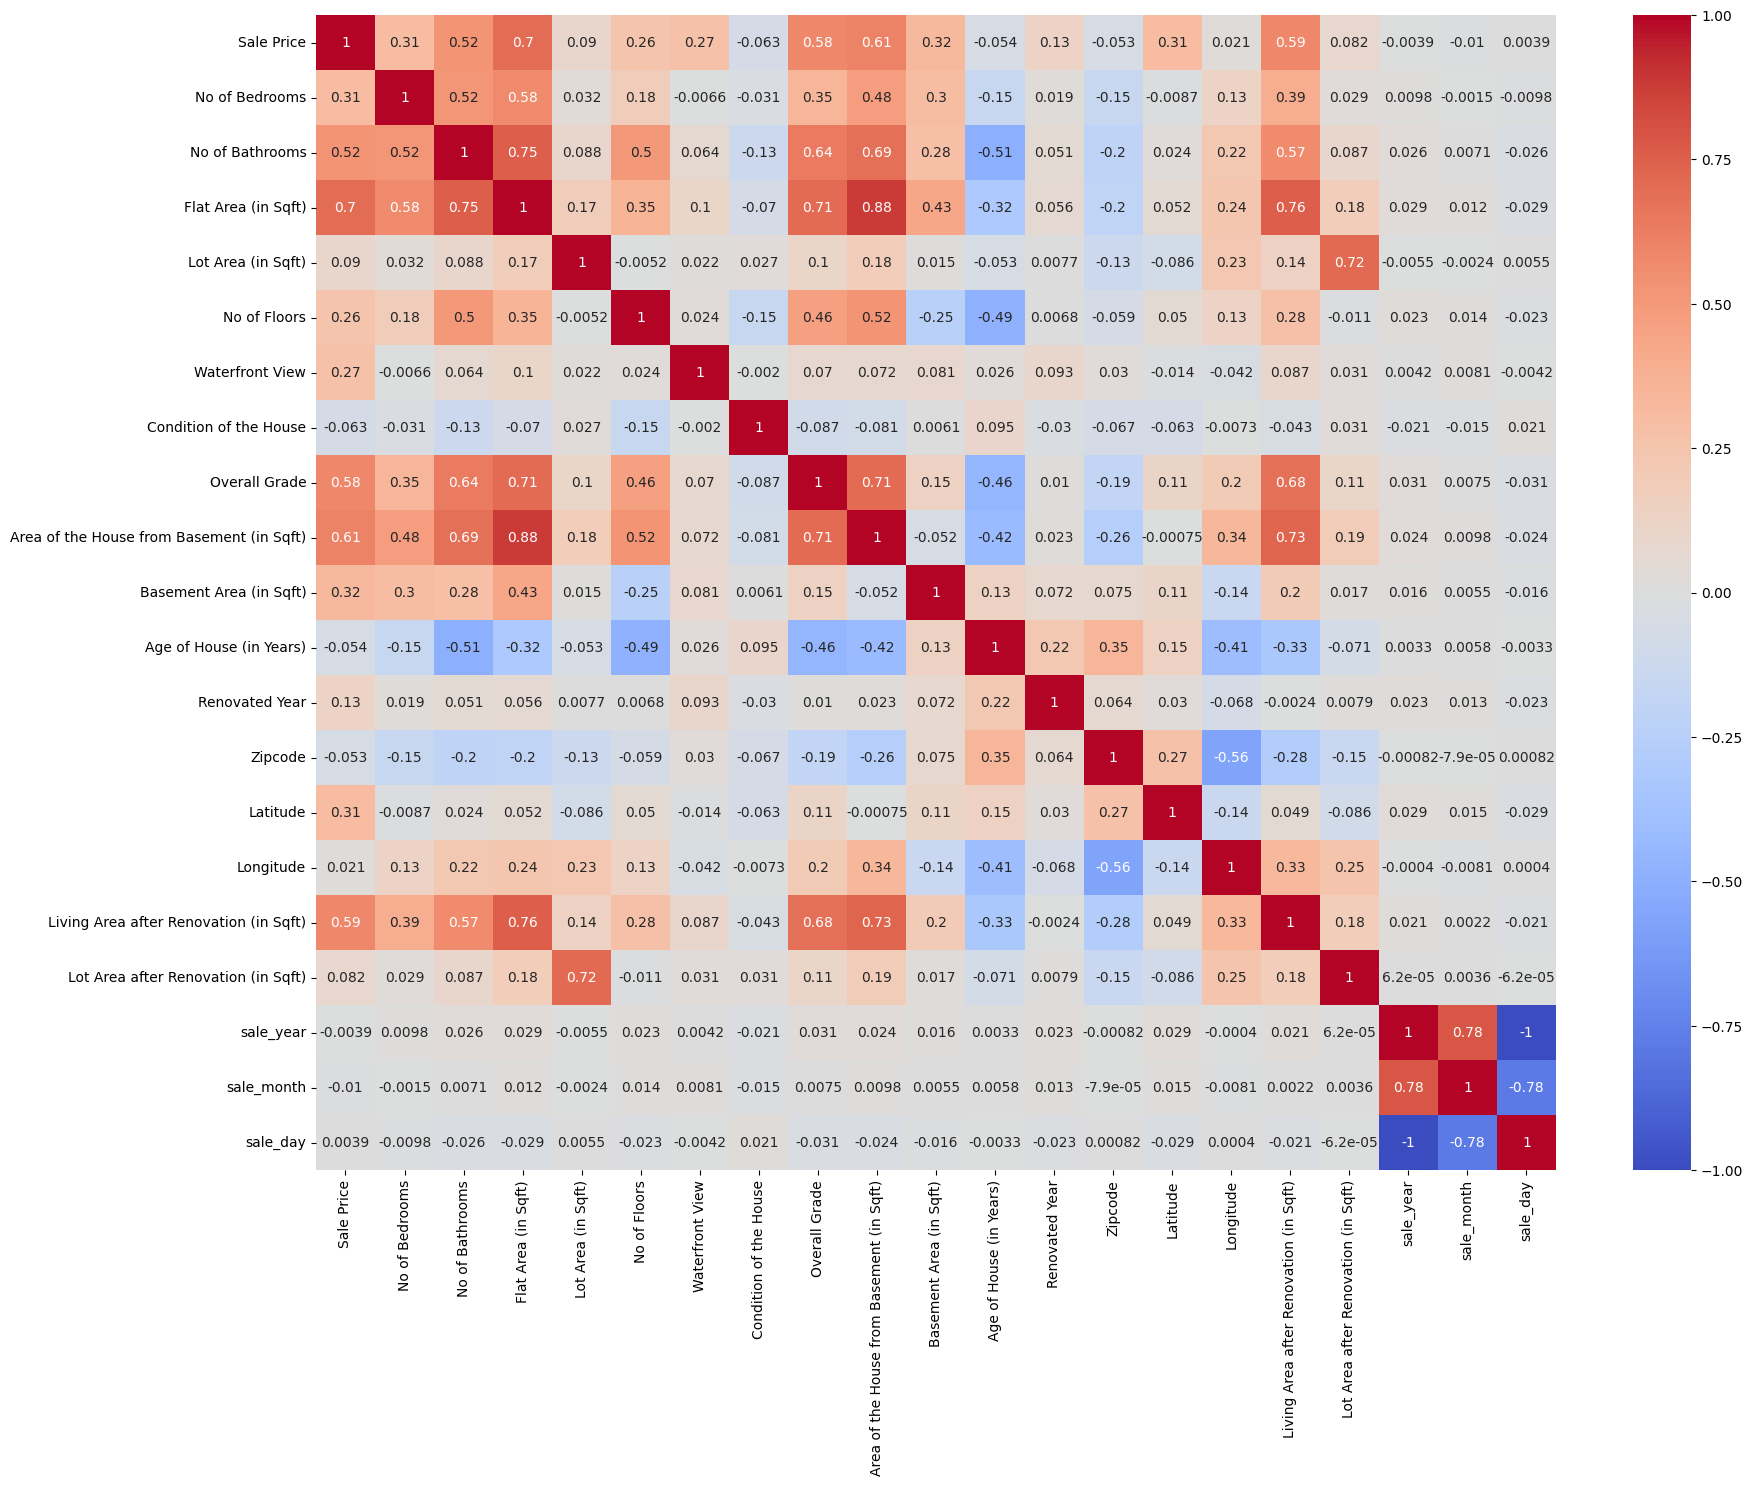

In [261]:
corr = df.select_dtypes(exclude="object").corr()

plt.figure(figsize=(20,15))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

In [262]:
# Selected features are as follows

columns_selected = ["Flat Area (in Sqft)", "Sale Price","No of Bathrooms","Basement Area (in Sqft)","Area of the House from Basement (in Sqft)"]

df = df[columns_selected]

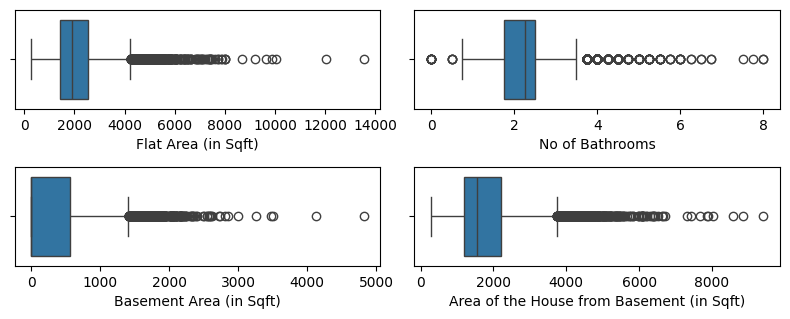

In [263]:
# Checking outliers on each columns

outlier_columns = ["Flat Area (in Sqft)","No of Bathrooms","Basement Area (in Sqft)","Area of the House from Basement (in Sqft)"]

plt.figure(figsize=(8, 6))

for i, col in enumerate(outlier_columns):
  plt.subplot(len(outlier_columns), 2, i + 1)
  sns.boxplot(x = df[col])

plt.tight_layout()
plt.show()

In [268]:
#handling using IQR

for c in outlier_columns:
  q1 = df[c].quantile(0.25)
  q3 = df[c].quantile(0.75)

  iqr = q3-q1
  upper_bound = q3+1.5*iqr
  lower_bound = q1-1.5*iqr

  outlier = df[(df[c] < lower_bound) | (df[c] > upper_bound)]
  df[c] = df[c].clip(upper = upper_bound,lower = lower_bound)
  df[c].describe()

In [269]:
df.head()


,Flat Area (in Sqft),Sale Price,No of Bathrooms,Basement Area (in Sqft),Area of the House from Basement (in Sqft)
0,1180.0,221900.0,1.00,0,1180.0
1,2570.0,538000.0,2.25,400,2170.0
2,770.0,180000.0,1.00,0,770.0
3,1960.0,604000.0,3.00,910,1050.0
4,1680.0,510000.0,2.00,0,1680.0


In [270]:
# Splitting data
X = df.drop(columns=["Sale Price"])
y = df["Sale Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [271]:
#Standardizing data
scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)